# 3.5 Multiple microtubule search

## Environment configuration

CPU: 13th Gen Intel(R) Core(TM) i7-13700K 64GB

python==3.13.9 torch==2.9.1

In [1]:
from tqdm import tqdm
import torch
from cibsde import nn, utils
import matplotlib.pyplot as plt
device = 'cpu'
seed = 666
torch.manual_seed(seed)

## Parameter settings

In [2]:
# model parameters
num_sphere = 1
t = torch.tensor(1.,device=device)
D = torch.tensor(0.1,device=device)
r = torch.tensor([1],device=device)
R = 2
N = 100
# training parameters
batch = 512
epoch = 10**4
lr = 1e-3
train_params = {
    'epoch': epoch,
    'batch': batch,
    'lr': lr
}

## Model initialization

In [3]:
def data_gen(batch):
    u1 = torch.rand([batch,num_sphere],device=device)
    u2 = torch.rand([batch,num_sphere],device=device)*(1-r/R/2)
    phi = 2 * torch.pi * u1
    theta = torch.arccos(1 - u2)
    theta[:,:-1] = 0
    x = torch.sin(theta) * torch.cos(phi)
    y = torch.sin(theta) * torch.sin(phi)
    z = torch.cos(theta)
    return torch.stack([x,y,z],dim=2).reshape([batch,num_sphere*3]).to(device)

def pc(i,x):
    x = x.reshape([batch*num_sphere,3])
    x_polar = utils.polar_corr(x).reshape([batch*num_sphere,2])
    return (x_polar[:,0]<torch.pi/4).reshape([batch,num_sphere]).prod(dim=1,keepdim=True).float()

def xb(x):
    thetab = torch.arccos(r[0]/R/2)
    x = x.reshape([batch*num_sphere,3])
    x_polar = utils.polar_corr(x).reshape([batch,num_sphere,2])
    in_ornot = (x_polar[:,:,0] < thetab).reshape([batch*num_sphere])
    xb_ = x_polar.clone()
    xb_[:,:,0] = thetab
    xb_ = utils.euclid_corr(xb_.reshape([batch*num_sphere,2]))
    nb_ = torch.cat([xb_[:,:1]*xb_[:,2:],xb_[:,1:2]*xb_[:,2:],-xb_[:,:2].norm(dim=1,keepdim=True)**2],dim=1)
    nb_ = nb_ / nb_.norm(dim=1,keepdim=True)
    return xb_, nb_, ~in_ornot

def hitb(x):
    return torch.zeros(batch,device=device).bool()

def h(t,x):
    return torch.zeros([batch,1],device=device)

def f(t,xt,p):
    return torch.zeros([batch,1],device=device)

model = nn.SphereIBSDE(
    dx = num_sphere,
    t = t,
    f = f,
    D = D/r**2,
    h = h,
    pc = pc,
    data_gen = data_gen,
    N = N,
    refb = xb,
    hitb = hitb
).to(device)

## Loading reference solution

In [4]:
y_rel = torch.load('./datasets/example5-1.pth')

## Model training

In [5]:
def train(model, params:dict):
    epoch = params['epoch']
    batch = params['batch']
    lr = params['lr']
    theta = torch.linspace(0,torch.arccos(r[-1]/R/2),101)
    phi = torch.linspace(0,torch.pi*2,200)
    theta,phi = torch.meshgrid(theta[:100],phi,indexing='ij')
    x_polar = torch.stack([theta.reshape(100*200),phi.reshape(100*200)],dim=1)
    x = utils.euclid_corr(x_polar).to(device)

    optim = torch.optim.Adam(model.parameters(),lr=lr)
    loss_fun = torch.nn.MSELoss()
    
    loss_values = torch.zeros(epoch)
    rel_error = torch.zeros(epoch)
    pbar = tqdm(range(epoch))
    for i in pbar:
        model.train()
        optim.zero_grad()
        u_pre, u_rel = model(batch)
        loss = loss_fun(u_pre,u_rel)
        loss.backward()
        optim.step()

        model.eval()
        loss_values[i] = loss.item()
        with torch.no_grad():
            pre = model.p(x).reshape([100,200]).detach()
            rel_error[i] = torch.sqrt(((pre - y_rel.to(device))**2).mean()/((y_rel.to(device)**2).mean()))
        pbar.set_postfix(loss='%e' % loss_values[i], error='%e' % rel_error[i])
    print("\nTraining has been completed.")
    return loss_values, rel_error

In [6]:
loss_value, rel_error = train(
    model,
    train_params
)

100%|██████████| 10000/10000 [24:05<00:00,  6.92it/s, error=2.750976e-02, loss=2.179665e-02]


Training has been completed.


## PINN

In [7]:
import cibsde.utils as utils
class PINN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.p = utils.FNN(4,1)
        self.r = r

    def forward(self, batch):
        u1 = torch.rand([batch,1],device=device)
        u2 = torch.rand([batch,1],device=device)*(1-self.r/R/2)

        phi = 2 * torch.pi * u1
        theta = torch.arccos(1 - u2)
        theta = theta[theta[:,0]>1e-4]
        phi = phi[:theta.shape[0]]

        phi.requires_grad = True
        theta.requires_grad = True

        x = torch.sin(theta) * torch.cos(phi)
        y = torch.sin(theta) * torch.sin(phi)
        z = torch.cos(theta)
        ps = torch.cat([x, y, z], dim=1)
        t = torch.rand([theta.shape[0],1],device=device,requires_grad=True)

        phib = 2 * torch.pi * torch.rand([batch,1],device=device)
        thetab = torch.ones([batch,1],device=device) * torch.arccos(self.r[0]/R/2)
        thetab.requires_grad = True

        xb1 = torch.sin(thetab) * torch.cos(phib)
        yb1 = torch.sin(thetab) * torch.sin(phib)
        zb1 = torch.cos(thetab)
        pbs1 = torch.cat([xb1, yb1, zb1], dim=1)
        tb = torch.rand([batch,1],device=device)

        u1 = torch.rand([batch,1],device=device)
        u2 = torch.rand([batch,1],device=device)*(1-self.r/R/2)

        phiT = 2 * torch.pi * u1
        thetaT = torch.arccos(1 - u2)

        xT = torch.sin(thetaT) * torch.cos(phiT)
        yT = torch.sin(thetaT) * torch.sin(phiT)
        zT = torch.cos(thetaT)
        psT = torch.cat([xT, yT, zT], dim=1)
        T = torch.ones([batch,1],device=device)

        sintheta = torch.sin(theta)
        u = self.p(torch.cat([t,ps],dim=1))
        grad_theta = torch.autograd.grad(u,theta,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
        grad_phi = torch.autograd.grad(u,phi,torch.ones_like(u),retain_graph=True,create_graph=True)[0]

        singrad_theta = torch.autograd.grad(grad_theta*sintheta,theta,torch.ones_like(grad_theta),retain_graph=True,create_graph=True)[0]

        grad2_phi = torch.autograd.grad(grad_phi,phi,torch.ones_like(grad_phi),retain_graph=True,create_graph=True)[0]
        ub = self.p(torch.cat([tb,pbs1],dim=1))
        grad_ub = torch.autograd.grad(ub,thetab,torch.ones_like(ub),retain_graph=True,create_graph=True)[0]

        ut = torch.autograd.grad(u,t,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
        uT = self.p(torch.cat([T,psT],dim=1))
        u_ = -(D*(singrad_theta/sintheta+grad2_phi/sintheta**2)/self.r**2).sum(dim=1,keepdim=True)
        return torch.cat([ut,grad_ub,uT]), torch.cat([u_,torch.zeros_like(grad_ub),pc(100,psT)])

## PINN initialization

In [8]:
pinn = PINN().to(device)

## PINN training

In [9]:
def train(model, params:dict):
    epoch = params['epoch']
    batch = params['batch']
    lr = params['lr']
    theta = torch.linspace(0,torch.arccos(r[-1]/R/2),101)
    phi = torch.linspace(0,torch.pi*2,200)
    theta,phi = torch.meshgrid(theta[:100],phi,indexing='ij')
    x_polar = torch.stack([theta.reshape(100*200),phi.reshape(100*200)],dim=1)
    x = utils.euclid_corr(x_polar).to(device)
    t = torch.ones([100*200,1],device=device)*0

    optim = torch.optim.Adam(model.parameters(),lr=lr)
    loss_fun = torch.nn.MSELoss()
    loss_values = torch.zeros(epoch)
    rel_error = torch.zeros(epoch)
    pbar = tqdm(range(epoch))
    for i in pbar:
        model.train()
        optim.zero_grad()
        u_pre, u_rel = model(batch)
        loss = loss_fun(u_pre,u_rel)
        loss.backward()
        optim.step()

        model.eval()
        loss_values[i] = loss.item()
        with torch.no_grad():
            pre = model.p(torch.cat([t,x],dim=1)).reshape([100,200])
            rel_error[i] = torch.sqrt(((pre - y_rel.to(device))**2).sum()/((y_rel.to(device)**2).sum()))
        pbar.set_postfix(loss='%e' % loss_values[i], error='%e' % rel_error[i])
    print("\nTraining has been completed.")
    return loss_values, rel_error

In [10]:
loss_values_pinn, rel_error_pinn = train(
    pinn,
    train_params
)

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [02:06<00:00, 78.82it/s, error=2.446745e-02, loss=9.980418e-03]


Training has been completed.


## Plot figures

In [11]:
theta = torch.linspace(0,torch.arccos(r[0]/R/2),101)
phi = torch.linspace(0,torch.pi*2,200)
theta,phi = torch.meshgrid(theta[:100],phi,indexing='ij')
x_polar = torch.stack([theta.reshape(100*200),phi.reshape(100*200)],dim=1)
x = utils.euclid_corr(x_polar)
x_pinn = torch.cat([torch.ones([100*200,1])*0,x],dim=1)
y_pinn = pinn.p(x_pinn.to(device)).reshape([100,200]).cpu().detach()
y_pre = model.p(x.to(device)).reshape([100,200]).cpu().detach()

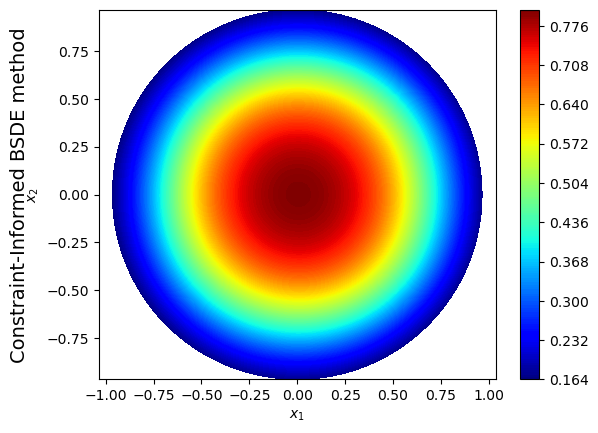

In [12]:
x = x.reshape([100,200,1,3])
plt.axis('equal')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.contourf(x[:,:,-1,0].cpu(),x[:,:,-1,1].cpu(),y_pre,200,cmap='jet')
plt.colorbar()
plt.text(
    -0.2, 0.5, 'Constraint-Informed BSDE method',
    transform=plt.gca().transAxes,
    rotation=90,
    fontsize=14,
    va='center',
    ha='center'
)
plt.savefig('./figures/multi_search_cibsde_lowdim_result.pdf', bbox_inches='tight', format='pdf',dpi=2000)
plt.show()

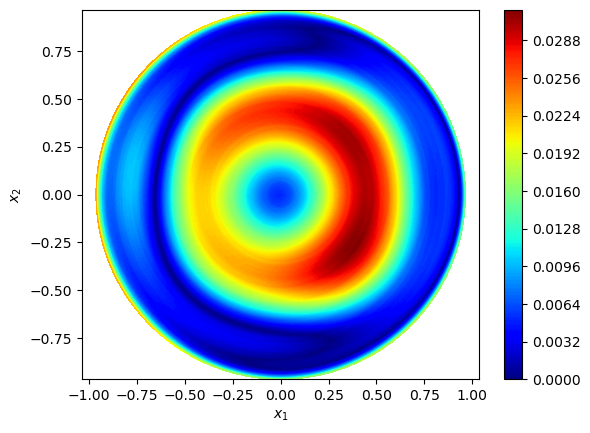

In [13]:
plt.axis('equal')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.contourf(x[:,:,-1,0].cpu(),x[:,:,-1,1].cpu(),(y_pre-y_rel).abs(),200,cmap='jet')
plt.colorbar()
plt.savefig('./figures/multi_search_cibsde_lowdim_error.pdf', bbox_inches='tight', format='pdf',dpi=2000)
plt.show()

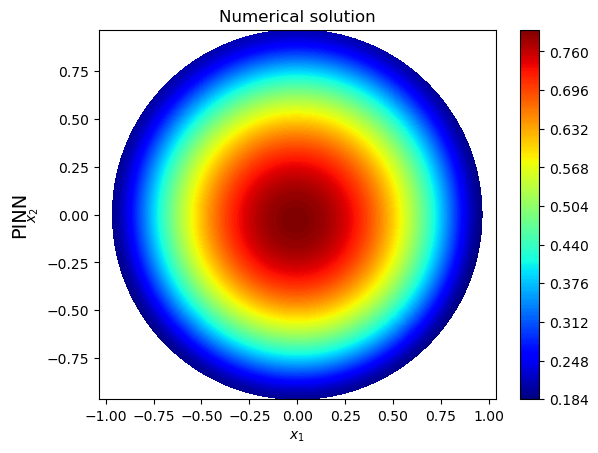

In [14]:
plt.axis('equal')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.contourf(x[:,:,-1,0].cpu(),x[:,:,-1,1].cpu(),y_pinn,200,cmap='jet')
plt.colorbar()
plt.title('Numerical solution')
plt.text(
    -0.2, 0.5, 'PINN',
    transform=plt.gca().transAxes,
    rotation=90,
    fontsize=14,
    va='center',
    ha='center'
)
plt.savefig('./figures/multi_search_pinn_lowdim_result.pdf', bbox_inches='tight', format='pdf',dpi=2000)
plt.show()

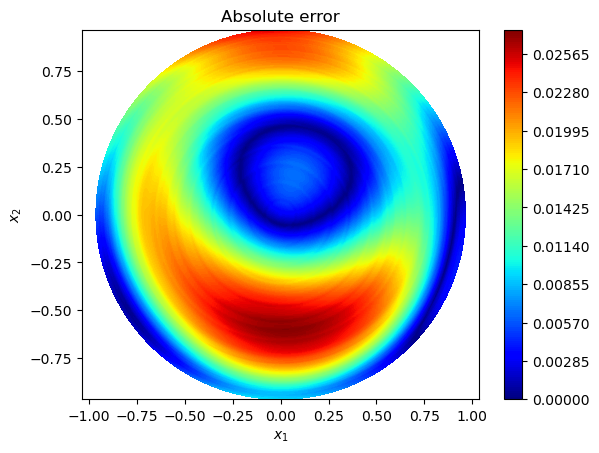

In [15]:
plt.axis('equal')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.contourf(x[:,:,-1,0].cpu(),x[:,:,-1,1].cpu(),(y_pinn-y_rel).abs(),200,cmap='jet')
plt.colorbar()
plt.title('Absolute error')
plt.savefig('./figures/multi_search_pinn_lowdim_error.pdf', bbox_inches='tight', format='pdf',dpi=2000)
plt.show()

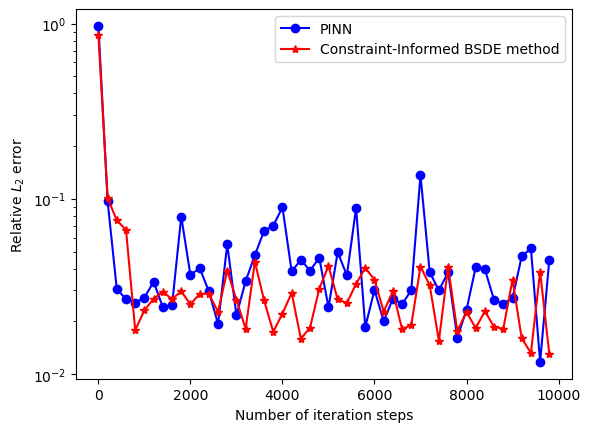

In [16]:
plt.yscale('log')
plt.xlabel('Number of iteration steps')
plt.ylabel('Relative $L_2$ error')
plt.plot(torch.arange(0,10**4)[::200],rel_error_pinn[::200],'o-',c='b',label='PINN')
plt.plot(torch.arange(0,10**4)[::200],rel_error[::200],'*-',c='r',label='Constraint-Informed BSDE method')
plt.legend()
plt.savefig('./figures/multi_search_lowdim_error.pdf',dpi=2000,format='pdf')
plt.show()